In [1]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
from hydrax.utils.files import get_data_path
from scipy.ndimage import uniform_filter1d  # Or use np.convolve



def rotmat(yaw: float) -> np.ndarray:
    c, s = math.cos(yaw), math.sin(yaw)
    return np.array([[c, -s],
                     [s,  c]])
    
def rectangle_corners(center_xy, width, height, yaw):
    cx, cy = center_xy
    R = rotmat(yaw)
    hw, hh = width / 2.0, height / 2.0
    local = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
    ])
    world = (local @ R.T) + np.array([cx, cy])
    return world

def t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h):
    stem_center_local = np.array([0.0, -head_h / 2.0])
    head_center_local = np.array([0.0,  stem_h / 2.0])

    stem_center_world = (stem_center_local @ rotmat(yaw).T) + np.array([x, y]) + np.array([0.0425, 0.0])
    head_center_world = (head_center_local @ rotmat(yaw).T) + np.array([x, y]) + np.array([0.0425, 0.0])

    stem_poly = rectangle_corners(stem_center_world, stem_w, stem_h, yaw)
    head_poly = rectangle_corners(head_center_world, head_w, head_h, yaw)
    return stem_poly, head_poly

def plot_action_space(ax, xmin, xmax, ymin, ymax, show_grid=False, grid_dx=0.25):
    ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1.5))
    if show_grid and grid_dx > 0:
        xv = np.arange(math.ceil(xmin / grid_dx) * grid_dx, xmax + 1e-9, grid_dx)
        yv = np.arange(math.ceil(ymin / grid_dx) * grid_dx, ymax + 1e-9, grid_dx)
        for xx in xv:
            ax.plot([xx, xx], [ymin, ymax], linewidth=0.4)
        for yy in yv:
            ax.plot([xmin, xmax], [yy, yy], linewidth=0.4)

def draw_t(ax, x, y, yaw_deg, stem_w, stem_h, head_w, head_h,
           face_alpha=0.4, edge_width=0.0, facecolor=None, edgecolor=None, label=None):
    yaw = yaw_deg#math.radians(yaw_deg)
    stem_poly, head_poly = t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h)
    poly_kwargs = dict(closed=True, alpha=face_alpha)
    if facecolor is not None:
        poly_kwargs["facecolor"] = facecolor
    if edgecolor is not None:
        poly_kwargs["edgecolor"] = edgecolor

    stem_patch = Polygon(stem_poly, **poly_kwargs, linewidth=edge_width)
    head_patch = Polygon(head_poly, **poly_kwargs, linewidth=edge_width)
    ax.add_patch(stem_patch)
    ax.add_patch(head_patch)
    if label:
        ax.text(x, y, label, ha="center", va="center", fontsize=10)
    return np.vstack([stem_poly, head_poly])


def quat_to_yaw_manual(qx, qy, qz, qw):
    # Normalize
    norm = np.sqrt(qx**2 + qy**2 + qz**2 + qw**2)
    qw /= norm; qx /= norm; qy /= norm; qz /= norm
    
    sin_yaw_2 = 2 * (qw * qz + qx * qy)
    cos_yaw_2 = 1 - 2 * (qy**2 + qz**2)
    yaw = np.arctan2(sin_yaw_2, cos_yaw_2)
    return np.rad2deg(yaw)

def subsample_to_target(data, target_steps=300):
    """Uniformly subsample data to target_steps if longer."""
    if len(data) <= target_steps:
        return data
    indices = np.linspace(0, len(data) - 1, target_steps, dtype=int)
    return [data[i] for i in indices]

import seaborn as sns
import pandas as pd
sns.set(font_scale=1.7, rc={'font.size':17, 'font.family':'serif'})

Loading data for version=bad, seed=10...
Loading data for version=bad, seed=11...
Loading data for version=bad, seed=12...
Loading data for version=uniform, seed=10...
Loading data for version=uniform, seed=11...
Loading data for version=uniform, seed=12...
Loading data for version=exp, seed=10...
Loading data for version=exp, seed=11...
Loading data for version=exp, seed=12...


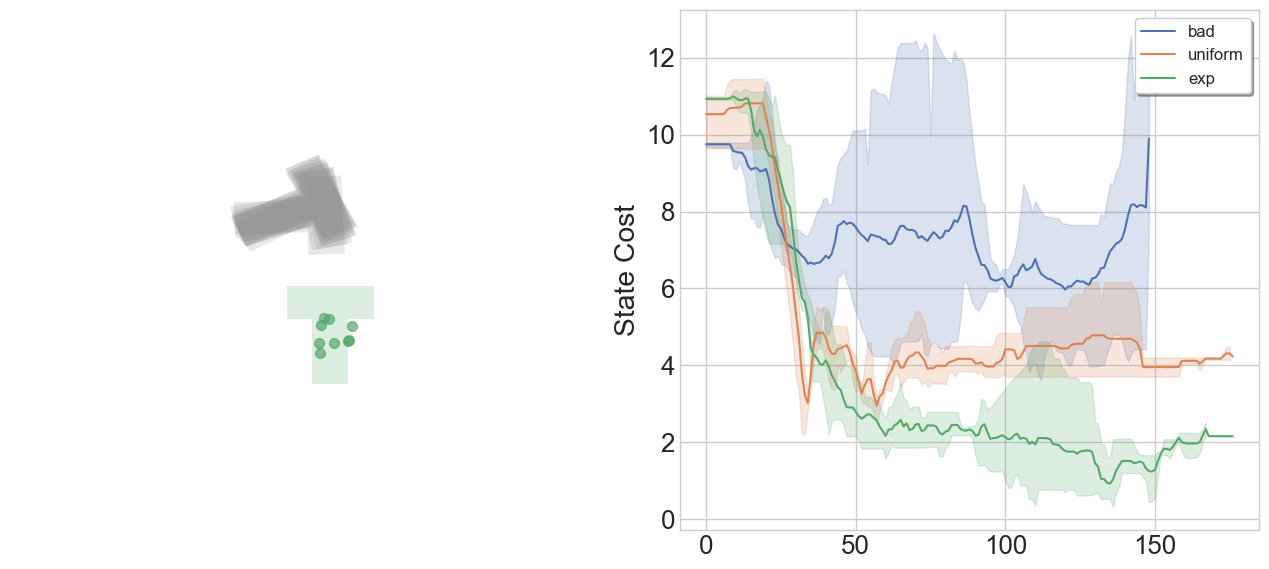

In [2]:
experiments = [[10,11,12]]


for seeds, idx in zip(experiments, range(len(experiments))):
    # Collect all data into long-form DataFrame
    df_list = []
    init_T = []

    for version in ["bad", "uniform", "exp"]:
        for seed in seeds:
            print(f"Loading data for version={version}, seed={seed}...")
            
            path = get_data_path() / "sim-real-dr" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
            with open(path, "rb") as f:
                data = pickle.load(f)
            
            data = subsample_to_target(data, target_steps=300)  
                
            quat = np.array(data[0]['object_quat'])
            # quat to yaw
            jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2])
            x = data[5]['object_pos'][0]
            y = data[5]['object_pos'][1]
    
            init_T.append(np.concatenate((np.array([x, y]), np.array([jaw]))))
            timestep = np.arange(min(400, len(data)))
            df_list.append(pd.DataFrame({
                'timestep': timestep,
                'terminal_error': [d["terminal_error"] for d in data[:400]],
                'version': version,
                'seed': seed
            }))

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    df = pd.concat(df_list)
    init_Ts = np.array(init_T)


    init_ee = np.ones((init_Ts.shape[0], 2)) * np.array([0.0425, 0.5])
    init_ee += np.random.uniform(-0.03, 0.03, size=init_ee.shape)
    # plot
    axes[0].scatter(init_ee[:, 0], init_ee[:, 1], s=50, c='C2', alpha=0.7, label='Initial end-effector')
    draw_t(axes[0], 0.0, 0.5, 0.0, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor='C2')

    # draw Ts
    for i in range(init_Ts.shape[0]):
        x, y, yaw = init_Ts[i]
        yaw += -np.pi/2
        draw_t(axes[0], -y, x, yaw, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor='C7')

    axes[0].set_xlim([-0.4, 0.4])
    axes[0].set_ylim([0.2, 1.0])
    # remove ticks
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    # remove border
    for spine in axes[0].spines.values():
        spine.set_visible(False)

    sns.lineplot(data=df, x='timestep', y='terminal_error', hue='version', ax=axes[1])
    if idx == 2:
        axes[1].set_xlabel("Planning Step")
    else:
        axes[1].set_xlabel("")
    axes[1].set_ylabel("State Cost")
    if idx == 0:
        axes[1].legend(
            loc='upper right',           # Position: 'upper right', 'lower center', etc.
            frameon=True,                # Box around legend
            fancybox=True,               # Rounded box
            shadow=True,                 # Drop shadow
            ncol=1,                      # Columns (1=vertical)
            fontsize=12                  # Text size
        )
    else:
        axes[1].legend_.remove()
    plt.tight_layout()
    plt.show()
    # save as pdf
    # fig.savefig(f"fr3_rollout_{idx}.pdf", bbox_inches='tight')

In [19]:
timesteps = 165
for seeds, idx in zip(experiments, range(len(experiments))):
    # Collect all data into long-form DataFrame
    df_list = []
    init_T = []

    for version in ["bad", "uniform", "exp"]:
        for seed in seeds:
            print(f"Loading data for version={version}, seed={seed}...")
            
            path = get_data_path() / "sim-real-dr" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
            with open(path, "rb") as f:
                data = pickle.load(f)
                print(data[0].keys())
            
            quat = np.array(data[0]['object_quat'])
            # quat to yaw
            jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2]) 

            timestep = np.arange(min(timesteps, len(data)))
            df_list.append(pd.DataFrame({
                'timestep': timestep,
                'terminal_error': [d["terminal_error"] for d in data[:timesteps]],
                'version': version,
                'seed': seed,
                'block_vel': [d["block_vel"] for d in data[:timesteps]],
                'distances': [d["distances"] for d in data[:timesteps]], 
                'object_pose': [d["object_pos"] + d['object_quat'] for d in data[:timesteps]],  # x, y, z, qx, qy, qz, qw
                'domain_weights': [d["domain_weights"] for d in data[:timesteps]] if version == "exp" else [None]*len(timestep),
            }))

    plt.style.use('seaborn-v0_8-whitegrid')
    # fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    df = pd.concat(df_list)
    
df_uniform = df[df['version'] == 'uniform']
df_exp = df[df['version'] == 'exp']

Loading data for version=bad, seed=10...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=bad, seed=11...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=bad, seed=12...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=uniform, seed=10...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances'])
Loading data for version=uniform, seed=11...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos', 'terminal_error', 'action', 'block_vel', 'distances', 'domain_weights'])
Loading data for version=uniform, seed=12...
dict_keys(['time', 'planning_time', 'object_pos', 'object_quat', 'ee_pos',

(9, 10)


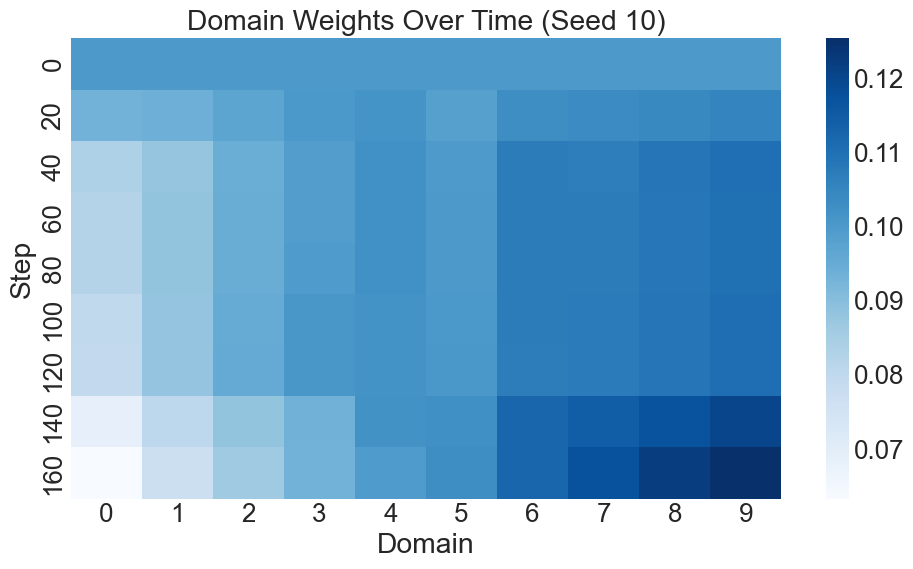

In [40]:
domain_weights = np.vstack(df_exp[df_exp['seed'] == 10]['domain_weights'].values)[::20]
print(domain_weights.shape)


# heatmap table of domain weights over time
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(domain_weights, ax=ax, cmap='Blues')
ax.set_xlabel('Domain')
ax.set_ylabel('Step')
ax.set_yticklabels(np.arange(0, domain_weights.shape[0]*20, 20))
ax.set_title('Domain Weights Over Time (Seed 10)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_453687/1197043581.py:67: RuntimeWarning: invalid value encountered in divide
  likelihoods = np.exp(-distances_exp/temperatures.reshape(-1, 1))
/tmp/ipykernel_453687/1197043581.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp[f'jensen_shannon_div_{factor}'] = jsd.copy()
/tmp/ipykernel_453687/1197043581.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp[f'normalized_entropy_{factor}'] = normalized_entropy.copy()
/tmp/ipykernel_453687/1197043581.py:67: RuntimeWarning: invali

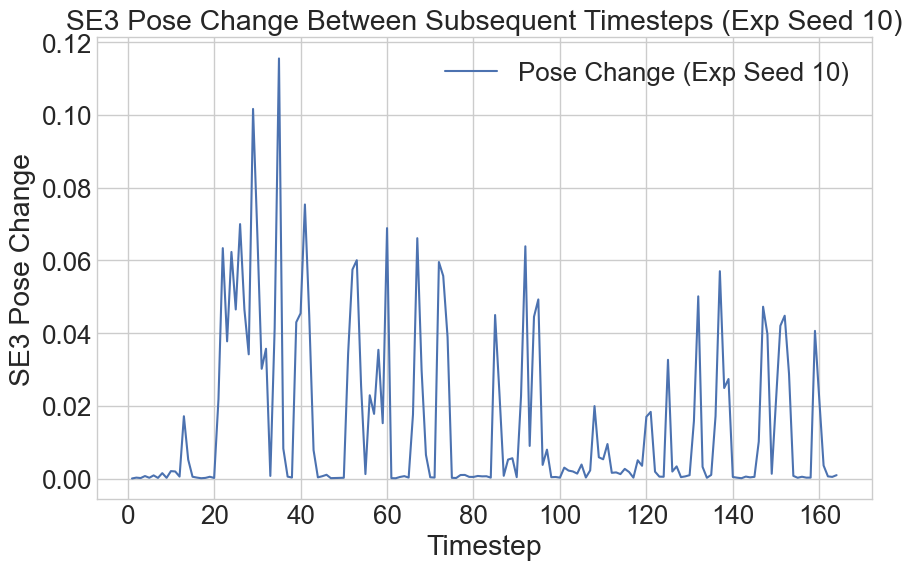

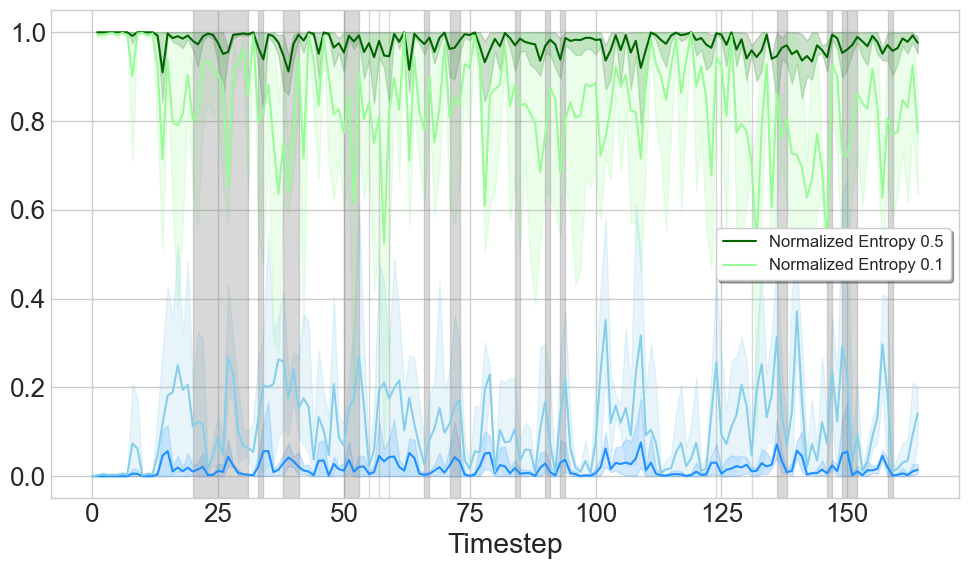

In [17]:
# compute SE3 error between subsequent poses
def se3_error(pose1, pose2):
    pos1, quat1 = pose1[:3], pose1[3:]
    pos2, quat2 = pose2[:3], pose2[3:]

    # Position error
    pos_error = np.linalg.norm(pos1 - pos2)

    # Orientation error (using quaternion distance)
    quat1 /= np.linalg.norm(quat1) + 1e-12
    quat2 /= np.linalg.norm(quat2) + 1e-12
    dot_product = np.clip(np.dot(quat1, quat2), -1.0, 1.0)
    orient_error = 2 * np.arccos(abs(dot_product))

    return pos_error + orient_error

def find_above_threshold_intervals(arr, threshold):
    above = arr > threshold
    indices = []
    current = False
    for idx in range(len(above)):
        if above[idx] and not current:
            start = idx
            current = True
        elif not above[idx] and current:
            end = idx - 1
            indices.append((start, end))
            current = False
    if current:
        indices.append((start, len(arr) - 1))
    return indices

def jensen_shannon_div(p, q):
    p = p / (np.sum(p) + 1e-12)
    q = q / (np.sum(q) + 1e-12)
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log((p + 1e-12) / (m + 1e-12)))
    kl_qm = np.sum(q * np.log((q + 1e-12) / (m + 1e-12)))
    return 0.5 * (kl_pm + kl_qm)


pose_errors = np.empty_like((timesteps-1,))
for seed in [10,11,12]:
    poses = np.vstack(df_exp[df_exp['seed'] == seed]['object_pose'].values)
    pose_errors = np.array([se3_error(poses[i], poses[i-1]) for i in range(1, len(poses))])
pose_errors /= 3.0   

threshold = 0.02
intervals = find_above_threshold_intervals(pose_errors, threshold)

plt.figure(figsize=(10, 6))
sns.lineplot(x=np.arange(1, len(poses)), y=pose_errors, label='Pose Change (Exp Seed 10)')
plt.xlabel('Timestep')
plt.ylabel('SE3 Pose Change')
plt.title('SE3 Pose Change Between Subsequent Timesteps (Exp Seed 10)')
plt.legend()


distances_exp = np.vstack(df_exp['distances'].values)

fig, ax = plt.subplots(figsize=(10, 6))
entropy_colors = ['darkgreen', 'palegreen']
jsd_colors = ['dodgerblue', 'skyblue']

for idx, factor in enumerate([0.5, 0.1]):
    temperatures = np.median(distances_exp, axis=1)*factor
    likelihoods = np.exp(-distances_exp/temperatures.reshape(-1, 1))
    sum_likelihoods = np.sum(likelihoods, axis=1)
    normalized_likelihoods = likelihoods / sum_likelihoods[:, np.newaxis]
    jsd = [
        jensen_shannon_div(normalized_likelihoods[i], normalized_likelihoods[i - 1])
        if i > 0 else 0.0
        for i in range(len(normalized_likelihoods))
    ]
    df_exp[f'jensen_shannon_div_{factor}'] = jsd.copy()

    entropy = -np.sum(
        normalized_likelihoods * np.log(normalized_likelihoods + 1e-12), axis=1
    )
    normalized_entropy = entropy / np.log(distances_exp.shape[1])
    df_exp[f'normalized_entropy_{factor}'] = normalized_entropy.copy()

    df_exp.reset_index(drop=True, inplace=True)
    sns.lineplot(
        x='timestep',
        y=f'normalized_entropy_{factor}',
        data=df_exp,
        color=entropy_colors[idx],
        label=f'Normalized Entropy {factor}',
        ax=ax
    )
    sns.lineplot(
        x='timestep',
        y=f'jensen_shannon_div_{factor}',
        data=df_exp,
        color=jsd_colors[idx],
        ax=ax
    )
for interval in intervals:
    start, end = interval
    ax.axvspan(start, end, color='grey', alpha=0.3)
plt.xlabel('Timestep')
plt.ylabel('')
ax.legend(
    loc='center right',           # Position: 'upper right', 'lower center', etc.
    frameon=True,                # Box around legend
    fancybox=True,               # Rounded box
    shadow=True,                 # Drop shadow
    ncol=1,                      # Columns (1=vertical)
    fontsize=12                  # Text size
)
plt.tight_layout()
plt.show()